In [16]:
import math #libreria (radici,arrotondamenti)
import time #prendo l'orario per calcolare il time execution
from collections import defaultdict #non interrompe in caso di missing
from itertools import combinations #mi serve assolutamente, devo prendere le associazioni generiche e non ordinate,combinations ([a,b,c],2)=(a,b),(a,c),(b,c)
import matplotlib.pyplot as plt
import pandas as pd

import glob #per cercare tramite * qualsiasi file es.(non ricordo Elio petri "Indagine su un cittadino al di sopra di ogni sopetto" e lo cerco come "*al di sopra di ogni sospetto")
import zipfile #leggo (e scrivo nel caso) lo zip dei film

pd.set_option("display.max_colwidth", 60) #massimo 60 caratteri per stringa in una cella elaborata

In [17]:
import os
os.environ["KAGGLE_USERNAME"] = "gianmarcocostanzo1"
os.environ["KAGGLE_KEY"] = "Gian!030198"
#devo sostituire le mie crednziali con 'XXXXXXX'
DATASET_LINK = "harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows"
CSV_PATH = "imdb_top_1000.csv"


In [18]:
if os.path.exists(CSV_PATH):
    print(f"'{CSV_PATH}' gia' presente: salto il download da Kaggle.")
else:
    print("Download del dataset da Kaggle...")
    get_ipython().system('kaggle datasets download -d {DATASET_LINK}') #

    zip_candidates = glob.glob("*.zip") #nella cartella di riferimeto di jupiter faccio il check di esistenza dello zip
    if not zip_candidates:
        raise RuntimeError(
            "Nessun file .zip trovato: il download da Kaggle non è andato a buon "
            "fine. Allora sempre controllare che KAGGLE_USERNAME e KAGGLE_KEY siano credenzialivalidi "
                  ) #zip_candidates = ['imdb-dataset-of-top-1000-movies-and-tv-shows.zip'] ad oggi e quindi ora lo apro per estrarlo
    with zipfile.ZipFile(zip_candidates[0], "r") as z: #'r' per 'reAad e dopo lo nomino z
        z.extractall(".") #il "." per estrarlo nella cartella corrente
    print(f"Estratto: {zip_candidates[0]}") 

    
print(f"Dataset pronto: {CSV_PATH}")


'imdb_top_1000.csv' gia' presente: salto il download da Kaggle.
Dataset pronto: imdb_top_1000.csv


In [19]:
df = pd.read_csv(CSV_PATH)
n_colonne = df.shape[1]
star_cols = ["Star1", "Star2", "Star3", "Star4"]  #lista con i nomi delle colonne

#Unico errore noto nel CSV originale: Apollo 13 ha "PG" al posto dell'anno, (sfasamento di colonna a monte), il film è del 1995
df.loc[df["Series_Title"] == "Apollo 13", "Released_Year"] = "1995" #sostituzione del parametro sbagliato tramite ".loc" funzione indicizzatrice
df["Released_Year"] = pd.to_numeric(df["Released_Year"]).astype(int) #converto la colonna in (int)
df["Decade"] = df["Released_Year"] // 10 * 10 #divisione intera che scarta il decimale e rimoltiplico

buchi = df[star_cols].isna().sum().sum() #isna -> True(1)/False(0) per ogni cella primo sum per colonna, secondo sul totale
assert buchi == 0, "trovati valori mancanti in Star1-4"

#CREO I BASKET con gli attori, itertuples perché una tabella pandas non si può scorrere riga per riga altrimenti
baskets = [frozenset(row) for row in df[star_cols].itertuples(index=False, name=None)]#name=None tupla nuda senza etichette index=False niente numero di riga
N = len(baskets)

item_counts_preview = defaultdict(int)
for b in baskets:
    for item in b:
        item_counts_preview[item] += 1

print(f"Film / basket: {N}   |   Colonne: {n_colonne}")
print(f"Anni: {df['Released_Year'].min()}-{df['Released_Year'].max()}   |   "
      f"Voto IMDB: {df['IMDB_Rating'].min()}-{df['IMDB_Rating'].max()} "
      f"(media {df['IMDB_Rating'].mean():.2f})")
print(f"Attori distinti (item): {len(item_counts_preview)}   |   "
      f"Registi distinti: {df['Director'].nunique()}")
print(f"Valori mancanti nelle colonne attori: {buchi}")

nulls = df.isna().sum()
nulls = nulls[nulls > 0]
print(f"\nValori mancanti nelle altre colonne:\n{nulls.to_string()}")

print("\nDimensione dei basket:")
for s, n in pd.Series([len(b) for b in baskets]).value_counts().sort_index().items():
    print(f"  {s} attori: {n} film")

by_dec = df.groupby("Decade").agg(film=("Series_Title", "count"),
                                  voto_medio=("IMDB_Rating", "mean")).round(2)
print("\nFilm per decennio:")
by_dec

Film / basket: 1000   |   Colonne: 16
Anni: 1920-2020   |   Voto IMDB: 7.6-9.3 (media 7.95)
Attori distinti (item): 2709   |   Registi distinti: 548
Valori mancanti nelle colonne attori: 0

Valori mancanti nelle altre colonne:
Certificate    101
Meta_score     157
Gross          169

Dimensione dei basket:
  3 attori: 4 film
  4 attori: 996 film

Film per decennio:


,film,voto_medio
Decade,,
1920,11,8.13
1930,24,7.97
1940,35,8.03
1950,56,8.06
1960,73,7.97
1970,76,7.97
1980,89,7.95
1990,151,7.96
2000,237,7.90


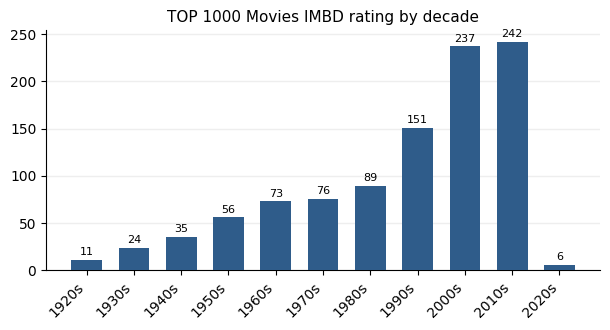

In [20]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
bars = ax.bar([f"{d}s" for d in by_dec.index], by_dec["film"], color="#2F5C8A", width=0.65, zorder=3)

ax.set_title("TOP 1000 Movies IMBD rating by decade", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#eeeeee", lw=1); ax.set_axisbelow(True) #Metto le righe comunque dietro le colonne
plt.xticks(rotation=45, ha="right") #ruoto i numerelli delle decadi

for bar, v in zip(bars, by_dec["film"]):
    ax.annotate(str(v), (bar.get_x() + bar.get_width()/2, bar.get_height()), #stringa col mio numerello che allineo al centro sopra il grafico
                 ha="center",va="bottom",fontsize=8,xytext=(0, 2), textcoords="offset points")

plt.tight_layout()
plt.savefig("figura_film_per_decennio.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [21]:
item_counts_preview = defaultdict(int) #default dict per non trovare errore in caso di missig
for b in baskets: #per ogni film (ogni riga o ogni insieme dei basket rappresenta un film)
    for item in b: #per ogni attore in quel film aggiorna il contatore
        item_counts_preview[item] += 1

print(f"Numero di attori distinti: {len(item_counts_preview)}")

top15 = sorted(item_counts_preview.items(), key=lambda x: -x[1])[:10]
top15_df = pd.DataFrame(top15, columns=["Attore", "Numero di film"])
top15_df.index = top15_df.index + 1
top15_df

Numero di attori distinti: 2709


,Attore,Numero di film
1,Robert De Niro,17
2,Tom Hanks,14
3,Al Pacino,13
4,Brad Pitt,12
5,Clint Eastwood,12
6,Christian Bale,11
7,Leonardo DiCaprio,11
8,Matt Damon,11
9,James Stewart,10
10,Michael Caine,9


In [22]:
#Soglia tarata sulla densità reale dei dati: s=3 tiene il 10% dei singleton (271/2709) e 25 coppie
#Con s=4 le coppie crollano a 5 con s=10 (l'1% del libro, Sez. 6.1.4) restano 9 attori e zero coppie
SUPPORT_THRESHOLD = 3

#A PRIORI: Classico giro in 2 step

# A-PRIORI, passo di conteggio: una sola passata sui basket per tutti i candidati di livello k
def count_candidates(baskets, candidates): 
    counts = defaultdict(int)
    cand_set = set(candidates) #set perchè elementa già hashati e immutabili, se frozenset non si può fare nemmeno add/remove
    for basket in baskets: #per ogni film
        for c in cand_set: #per ogni candidato
            if c.issubset(basket): #se c è un sottoinsieme di basket aumento il contatore di c
                counts[c] += 1
    return counts


def apriori_gen(prev_frequent_itemsets, k):    
    prev_list = list(prev_frequent_itemsets) #converto subito in lista perchè poi accedo a una certa posizione, ruota[i]
    candidates = set() #creo set vuoto
    n = len(prev_list)
    for i in range(n): #Per ogni frequente nel giro presente (singletond, soubleton, etc)
        for j in range(i + 1, n): #unisco 2 successivi
            union = prev_list[i] | prev_list[j]
            if len(union) == k: #se raggiugno k AB+AC=ABC
                if all(frozenset(s) in prev_frequent_itemsets for s in combinations(union, k - 1)): #controllo che tutti i minori siano presenti nel precedente frequent itemset
                    candidates.add(union) 
    return candidates


def apriori(baskets, support_threshold):
    stats = [] #lista vuota
    t0 = time.perf_counter() 
    item_counts = defaultdict(int) #setto con il solito defaultdict
    for basket in baskets:
        for item in basket:
            item_counts[frozenset([item])] += 1
    frequent = {k_: v for k_, v in item_counts.items() if v >= support_threshold} #riempo k_,v con l'oggetto di item_counts ({'gianmarco costanzo'}):3, ...
    all_frequent = dict(frequent)
    stats.append({"k": 1, "num_candidati": len(item_counts), "num_frequenti": len(frequent)})

    k = 2
    prev_frequent = frequent #Passo i singleton
    while prev_frequent:
        candidates = apriori_gen(prev_frequent, k) #inizialmente k=2 , 271 singleton, permuto e ho 271!/269!*2!= 36585
        if not candidates:
            break #else sottointeso
        counts = count_candidates(baskets, candidates) #conta i candidati su tutte le coppie o sulle triple
        frequent = {c: v for c, v in counts.items() if v >= support_threshold} #stesso ragionamento del frequent
        stats.append({"k": k, "num_candidati": len(candidates), "num_frequenti": len(frequent)})
        all_frequent.update(frequent)
        prev_frequent = frequent
        k += 1

    elapsed = time.perf_counter() - t0
    return all_frequent, stats, elapsed


In [23]:
apriori_freq, apriori_stats, apriori_time = apriori(baskets, SUPPORT_THRESHOLD)

print(f"Tempo A-Priori: {apriori_time:.3f} s")
print(f"Totale itemset frequenti trovati: {len(apriori_freq)}\n")
stats_df=pd.DataFrame(apriori_stats)
stats_df.index = stats_df.index + 1
stats_df

Tempo A-Priori: 10.238 s
Totale itemset frequenti trovati: 299



,k,num_candidati,num_frequenti
1,1,2709,271
2,2,36585,25
3,3,4,3


In [24]:
def show_top(freq, size, top_n=10): #Filtra gli itemset frequenti di una data dimensione e ne mostra i top_n per support.
    items = [(sorted(k), v) for k, v in freq.items() if len(k) == size] #Prima di tutto faccio una lista per ordinare correttamente e sorto subito i nomi in ordine alfabetico
    items.sort(key=lambda x: -x[1]) #guardo l'elemento [1] di sort, cioè il support e grazie al "-" ordino fecrescete
    return pd.DataFrame(items[:top_n], columns=[f"Itemset (size {size})", "Support"])

for size in [2, 3, 4]: #ciclo e stampo gli itemset
    print(f"--- Top itemset frequenti di dimensione {size} ---")
    display_df = show_top(apriori_freq, size)
    print(display_df if not display_df.empty else "(nessuno)")
    print()


--- Top itemset frequenti di dimensione 2 ---
                   Itemset (size 2)  Support
0  [Daniel Radcliffe, Rupert Grint]        6
1   [Daniel Radcliffe, Emma Watson]        5
2       [Emma Watson, Rupert Grint]        5
3       [Joe Pesci, Robert De Niro]        4
4            [Tim Allen, Tom Hanks]        4
5         [Al Pacino, Diane Keaton]        3
6   [Christian Bale, Michael Caine]        3
7       [Al Pacino, Robert De Niro]        3
8       [Elijah Wood, Ian McKellen]        3
9      [Elijah Wood, Orlando Bloom]        3

--- Top itemset frequenti di dimensione 3 ---
                                Itemset (size 3)  Support
0  [Daniel Radcliffe, Emma Watson, Rupert Grint]        5
1     [Elijah Wood, Ian McKellen, Orlando Bloom]        3
2    [Carrie Fisher, Harrison Ford, Mark Hamill]        3

--- Top itemset frequenti di dimensione 4 ---
(nessuno)



In [25]:
#Passo 1 (una scansione): conta i singoli item e, allo stesso tempo, fai l'hash di ogni coppia dentro il basket in una tabella hash con NUM_BUCKETS bucket, incrementando il contatore del bucket.
#Trasforma la tabella hash in una bitmap dei bucket "frequenti" (count >= soglia).
#Passo 2 (seconda scansione): una coppia {a, b} diventa candidata solo se entrambi gli item sono frequenti e la coppia hash-a in un bucket frequente. Solo queste coppie candidate vengono effettivamente contate.
#Il punto centrale del confronto: PCY tipicamente genera molte meno coppie candidate di A-Priori (che candida tutte le C(f,2) coppie di item frequenti), a costo di un po' di memoria per la tabella hash nel primo passo.

def pcy_frequent_pairs(baskets, support_threshold, num_buckets): #Trova le coppie frequenti con PCY. Restituisce (dict coppia->support, info).
    t0 = time.perf_counter()

    #Passo 1: conto singoli item + hash delle coppie nei bucket
    item_counts = defaultdict(int)
    bucket_counts = defaultdict(int)
    for basket in baskets:
        items = sorted(basket) #Ordino gli attori dentro i singoli basket
        for item in items:
            item_counts[item] += 1
        for a, b in combinations(items, 2):#genero tutte le combinazioni possibili dalla lista e le hasho
            h = hash((a, b)) % num_buckets
            bucket_counts[h] += 1

    frequent_items = {i for i, c in item_counts.items() if c >= support_threshold}
    frequent_buckets = {h for h, c in bucket_counts.items() if c >= support_threshold}

    #Passo 2: ricostruisco solo le coppie "candidate" e le conto
    candidate_pairs = set()
    for basket in baskets:
        items = sorted(x for x in basket if x in frequent_items) #guardo gli attori nei basket e tefo solo i freeuquenti sortati
        for a, b in combinations(items, 2):
            h = hash((a, b)) % num_buckets
            if h in frequent_buckets:
                candidate_pairs.add(frozenset([a, b]))

    pair_counts = count_candidates(baskets, candidate_pairs)
    frequent_pairs = {p: v for p, v in pair_counts.items() if v >= support_threshold}
    elapsed = time.perf_counter() - t0

    #per confronto: quante coppie candiderebbe A-Priori (tutte le coppie di item frequenti)
    naive_apriori_candidates = len(list(combinations(sorted(frequent_items), 2)))

    info = {
        "num_item_distinti": len(item_counts),
        "num_item_frequenti": len(frequent_items),
        "num_buckets": num_buckets,
        "num_bucket_frequenti": len(frequent_buckets),
        "num_coppie_candidate_PCY": len(candidate_pairs),
        "num_coppie_candidate_APriori": naive_apriori_candidates,
        "num_coppie_frequenti": len(frequent_pairs),
        "tempo_secondi": elapsed,
    }
    return frequent_pairs, info


In [26]:
NUM_BUCKETS = 70000  #da provare altre valorizzazioni
pcy_freq_pairs, pcy_info = pcy_frequent_pairs(baskets, SUPPORT_THRESHOLD, NUM_BUCKETS)
pd.Series(pcy_info)


num_item_distinti                2709.000000
num_item_frequenti                271.000000
num_buckets                     70000.000000
num_bucket_frequenti               44.000000
num_coppie_candidate_PCY           33.000000
num_coppie_candidate_APriori    36585.000000
num_coppie_frequenti               25.000000
tempo_secondi                       0.017412
dtype: float64

In [27]:
#Sanity check: PCY deve trovare esattamente le stesse coppie frequenti di A-Priori
apriori_pairs = {k: v for k, v in apriori_freq.items() if len(k) == 2}
assert apriori_pairs == pcy_freq_pairs, "PCY e A-Priori non concordano: controlla l'implementazione!"
print("OK: le coppie frequenti trovate da PCY coincidono con quelle di A-Priori.")


OK: le coppie frequenti trovate da PCY coincidono con quelle di A-Priori.


In [28]:
comparison = pd.DataFrame([
    {
        "Metrica": "Coppie candidate da contare",
        "A-Priori": pcy_info["num_coppie_candidate_APriori"],
        "PCY": pcy_info["num_coppie_candidate_PCY"],
    },
    {
        "Metrica": "Coppie frequenti trovate",
        "A-Priori": len(apriori_pairs),
        "PCY": pcy_info["num_coppie_frequenti"],
    },
    {
        "Metrica": "Tempo totale (s)",
        "A-Priori": round(apriori_time, 3),
        "PCY": round(pcy_info["tempo_secondi"], 3),
    },
])
comparison


,Metrica,A-Priori,PCY
0,Coppie candidate da contare,36585.000,33.000
1,Coppie frequenti trovate,25.000,25.000
2,Tempo totale (s),10.238,0.017


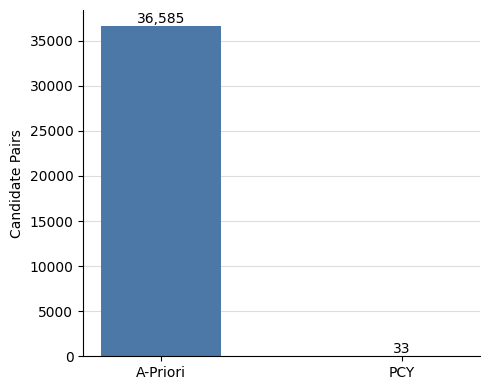

In [32]:
#Grafico: coppie candidate da contare, A-Priori vs PCY ---
fig, ax = plt.subplots(figsize=(5, 4))

labels = ["A-Priori", "PCY"]
values = [pcy_info["num_coppie_candidate_APriori"], pcy_info["num_coppie_candidate_PCY"]]
color = "#4C78A8"  # singola tinta: stiamo confrontando una grandezza, non categorie diverse

bars = ax.bar(labels, values, color=color, width=0.5)
ax.set_ylabel("Candidate Pairs")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for bar, v in zip(bars, values):
    ax.annotate(f"{v:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("figura_apriori_vs_pcy.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


In [30]:
def generate_rules(freq, N, min_confidence=0.5):
    # Da ogni itemset frequente I U {j}, genera la regola I -> j (confidence, interest).
    rules = []
    for itemset, support_ij in freq.items():
        if len(itemset) < 2:
            continue
        for j in itemset:
            antecedent = itemset - frozenset([j])
            support_i = freq.get(antecedent)
            if support_i is None:
                continue
            confidence = support_ij / support_i
            support_j = freq.get(frozenset([j]), 0)
            interest = confidence - (support_j / N)
            if confidence >= min_confidence:
                rules.append({
                    "Regola": f"{sorted(antecedent)} -> {j}",
                    "Support": support_ij,
                    "Confidence": round(confidence, 3),
                    "Interest": round(interest, 3),
                })
    rules.sort(key=lambda r: (-r["Confidence"], -r["Support"]))
    return pd.DataFrame(rules)

rules_df = generate_rules(apriori_freq, N, min_confidence=0.5)
print(f"Regole trovate (confidence >= 0.5): {len(rules_df)}")
rules_df.head(15)


Regole trovate (confidence >= 0.5): 39


,Regola,Support,Confidence,Interest
0,['Rupert Grint'] -> Daniel Radcliffe,6,1.0,0.994
1,['Daniel Radcliffe'] -> Rupert Grint,6,1.0,0.994
2,"['Emma Watson', 'Rupert Grint'] -> Daniel Radcliffe",5,1.0,0.994
3,"['Daniel Radcliffe', 'Emma Watson'] -> Rupert Grint",5,1.0,0.994
4,['Tim Allen'] -> Tom Hanks,4,1.0,0.986
5,['Elijah Wood'] -> Ian McKellen,3,1.0,0.993
6,['Elijah Wood'] -> Orlando Bloom,3,1.0,0.996
7,['Mark Hamill'] -> Harrison Ford,3,1.0,0.992
8,['Mark Hamill'] -> Carrie Fisher,3,1.0,0.996
9,['John Turturro'] -> Ethan Coen,3,1.0,0.994
